In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import math


## RNN code

In [44]:


class MDRNN(nn.Module):
    """Mixture Density RNN for CartPole world model.
    
    Predicts next state distribution as a Gaussian Mixture Model.
    State: [x, x_dot, theta, theta_dot] (4D)
    Action: discrete (0 or 1) for left/right
    """
    
    def __init__(self, state_dim=4, action_dim=1, hidden_dim=256, 
                 n_gaussian=5, n_layers=1):
        super().__init__()
        
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.hidden_dim = hidden_dim
        self.n_gaussian = n_gaussian
        self.n_layers = n_layers
        
        # LSTM that processes state+action sequences
        self.lstm = nn.LSTM(
            state_dim + action_dim, 
            hidden_dim, 
            n_layers, 
            batch_first=True
        )
        
        # Simplified output heads - using diagonal covariance for simplicity
        self.pi_head = nn.Linear(hidden_dim, n_gaussian)
        self.mu_head = nn.Linear(hidden_dim, n_gaussian * state_dim)
        self.sigma_head = nn.Linear(hidden_dim, n_gaussian * state_dim)
        
        # Optional: predict reward
        self.reward_head = nn.Linear(hidden_dim, 1)
        
        # Optional: predict done flag
        self.done_head = nn.Linear(hidden_dim, 1)
        
    def forward(self, states, actions, hidden=None):
        """
        Args:
            states: (batch, seq_len, state_dim)
            actions: (batch, seq_len, action_dim)
            hidden: tuple of (h, c) for LSTM hidden states
        
        Returns:
            pi: mixture weights (batch, seq_len, n_gaussian)
            mu: means (batch, seq_len, n_gaussian, state_dim)
            sigma: std devs (batch, seq_len, n_gaussian, state_dim)
            hidden: updated LSTM hidden state
        """
        batch_size, seq_len = states.shape[:2]
        
        # Concatenate state and action
        x = torch.cat([states, actions], dim=-1)
        
        # Process through LSTM
        lstm_out, hidden = self.lstm(x, hidden)
        
        # Compute mixture parameters
        pi = self.pi_head(lstm_out).view(batch_size, seq_len, self.n_gaussian)
        mu = self.mu_head(lstm_out).view(batch_size, seq_len, self.n_gaussian, self.state_dim)
        sigma = self.sigma_head(lstm_out).view(batch_size, seq_len, self.n_gaussian, self.state_dim)
        
        # Apply activations
        pi = F.softmax(pi, dim=-1)  # Normalize mixture weights
        sigma = F.softplus(sigma) + 1e-6  # Ensure positive std dev
        
        # Optional outputs
        reward = self.reward_head(lstm_out)
        done_logit = self.done_head(lstm_out)
        
        return {
            'pi': pi,
            'mu': mu, 
            'sigma': sigma,
            'reward': reward,
            'done_logit': done_logit,
            'hidden': hidden
        }
    
    def sample_prediction(self, pi, mu, sigma, temperature=1.0):
        """Sample next state from the mixture distribution.
        
        Args:
            pi: (n_gaussian,)
            mu: (n_gaussian, state_dim)
            sigma: (n_gaussian, state_dim)
            temperature: sampling temperature
        
        Returns:
            next_state: (state_dim,)
        """
        # Sample mixture component
        k = torch.multinomial(pi, 1).item()
        
        # Sample from the selected gaussian
        mean = mu[k]
        std = sigma[k] * temperature
        next_state = torch.normal(mean, std)
        
        return next_state
    
    def init_hidden(self, batch_size, device):
        """Initialize LSTM hidden state."""
        h = torch.zeros(self.n_layers, batch_size, self.hidden_dim, device=device)
        c = torch.zeros(self.n_layers, batch_size, self.hidden_dim, device=device)
        return (h, c)


def mdn_loss(pi, mu, sigma, target, reduce=True):
    """Negative log-likelihood loss for mixture density network.
    
    Args:
        pi: (batch, seq_len, n_gaussian)
        mu: (batch, seq_len, n_gaussian, state_dim)
        sigma: (batch, seq_len, n_gaussian, state_dim)
        target: (batch, seq_len, state_dim) - actual next states
    
    Returns:
        loss: scalar or (batch, seq_len) depending on reduce
    """
    # Expand target for broadcasting
    target = target.unsqueeze(2)  # (batch, seq_len, 1, state_dim)
    
    # Compute gaussian probabilities
    variance = sigma ** 2
    log_prob = -0.5 * ((target - mu) ** 2) / variance
    log_prob = log_prob - 0.5 * torch.log(2 * math.pi * variance)
    
    # Sum over state dimensions
    log_prob = log_prob.sum(dim=-1)  # (batch, seq_len, n_gaussian)
    
    # Weight by mixture coefficients
    weighted_log_prob = log_prob + torch.log(pi + 1e-8)
    
    # LogSumExp for numerical stability
    max_log_prob = weighted_log_prob.max(dim=-1, keepdim=True)[0]
    log_sum_exp = max_log_prob + torch.log(torch.exp(weighted_log_prob - max_log_prob).sum(dim=-1, keepdim=True))
    
    nll = -log_sum_exp.squeeze(-1)
    
    if reduce:
        return nll.mean()
    return nll

# Train the MD-RNN
def train_mdrnn(env, mdrnn, n_episodes=1000, lr=1e-3, seq_len=50):
    """Train the MD-RNN on CartPole environment."""
    
    optimizer = torch.optim.Adam(mdrnn.parameters(), lr=lr)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    mdrnn = mdrnn.to(device)
    
    # Track losses
    total_losses = []
    state_losses = []
    reward_losses = []
    done_losses = []
    
    for episode in range(n_episodes):
        state, _ = env.reset()
        states, actions, next_states, rewards, dones = [], [], [], [], []
        
        # Collect trajectory
        for _ in range(seq_len):
            action = env.action_space.sample()
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            
            states.append(state)
            actions.append([action])
            next_states.append(next_state)
            rewards.append(reward)
            dones.append(done)
            
            state = next_state
            if done:
                state, _ = env.reset()
        
        # Convert to tensors
        states = torch.FloatTensor(states).unsqueeze(0).to(device)
        actions = torch.FloatTensor(actions).unsqueeze(0).to(device)
        next_states = torch.FloatTensor(next_states).unsqueeze(0).to(device)
        rewards = torch.FloatTensor(rewards).unsqueeze(0).unsqueeze(-1).to(device)
        dones = torch.FloatTensor(dones).unsqueeze(0).unsqueeze(-1).to(device)
        
        # Forward pass
        hidden = mdrnn.init_hidden(1, device)
        outputs = mdrnn(states, actions, hidden)
        
        # Compute losses
        state_loss = mdn_loss(outputs['pi'], outputs['mu'], outputs['sigma'], next_states)
        reward_loss = F.mse_loss(outputs['reward'], rewards)
        done_loss = F.binary_cross_entropy_with_logits(outputs['done_logit'], dones)
        
        total_loss = state_loss + 0.1 * reward_loss + 0.1 * done_loss
        
        # Store losses
        total_losses.append(total_loss.item())
        state_losses.append(state_loss.item())
        reward_losses.append(reward_loss.item())
        done_losses.append(done_loss.item())
        
        # Backward pass
        optimizer.zero_grad()
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(mdrnn.parameters(), 10.0)
        optimizer.step()
        
        if episode % 100 == 0:
            print(f"Episode {episode}, Loss: {total_loss.item():.4f}, "
                  f"State Loss: {state_loss.item():.4f}")
    
    # Plot training losses
    plot_training_losses(total_losses, state_losses, reward_losses, done_losses)
    
    return {
        'total_losses': total_losses,
        'state_losses': state_losses,
        'reward_losses': reward_losses,
        'done_losses': done_losses
    }

def plot_training_losses(total_losses, state_losses, reward_losses, done_losses):
    """Plot training losses over episodes."""
    
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
    
    episodes = range(len(total_losses))
    
    # Total loss
    ax1.plot(episodes, total_losses, 'b-', alpha=0.7)
    ax1.set_title('Total Loss')
    ax1.set_xlabel('Episode')
    ax1.set_ylabel('Loss')
    ax1.grid(True, alpha=0.3)
    
    # Add smoothed line for total loss
    if len(total_losses) > 50:
        window = min(100, len(total_losses) // 10)
        smoothed = np.convolve(total_losses, np.ones(window)/window, mode='valid')
        ax1.plot(range(window-1, len(total_losses)), smoothed, 'r-', linewidth=2, label='Smoothed')
        ax1.legend()
    
    # State loss (main component)
    ax2.plot(episodes, state_losses, 'g-', alpha=0.7)
    ax2.set_title('State Prediction Loss (MDN)')
    ax2.set_xlabel('Episode')
    ax2.set_ylabel('Loss')
    ax2.grid(True, alpha=0.3)
    
    # Reward loss
    ax3.plot(episodes, reward_losses, 'orange', alpha=0.7)
    ax3.set_title('Reward Prediction Loss')
    ax3.set_xlabel('Episode')
    ax3.set_ylabel('MSE Loss')
    ax3.grid(True, alpha=0.3)
    
    # Done loss
    ax4.plot(episodes, done_losses, 'purple', alpha=0.7)
    ax4.set_title('Done Prediction Loss')
    ax4.set_xlabel('Episode')
    ax4.set_ylabel('BCE Loss')
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print final statistics
    print(f"\nTraining Complete!")
    print(f"Final Total Loss: {total_losses[-1]:.4f}")
    print(f"Final State Loss: {state_losses[-1]:.4f}")
    print(f"Final Reward Loss: {reward_losses[-1]:.4f}")
    print(f"Final Done Loss: {done_losses[-1]:.4f}")
    
    # Show improvement
    if len(total_losses) > 100:
        initial_avg = np.mean(total_losses[:100])
        final_avg = np.mean(total_losses[-100:])
        improvement = ((initial_avg - final_avg) / initial_avg) * 100
        print(f"Loss improvement: {improvement:.1f}% (from {initial_avg:.4f} to {final_avg:.4f})")



## Train

In [ ]:
import os
# Create trained_models directory if it doesn't exist
os.makedirs('trained_models', exist_ok=True)

hidden_dim = 256
training_episodes = 15000



Episode 0, Loss: 3.0096, State Loss: 2.8372
Episode 100, Loss: 0.3738, State Loss: 0.3434
Episode 200, Loss: -3.3261, State Loss: -3.3550
Episode 300, Loss: -5.5271, State Loss: -5.5483
Episode 400, Loss: -6.3854, State Loss: -6.4116
Episode 500, Loss: -7.1183, State Loss: -7.1322
Episode 600, Loss: -5.9039, State Loss: -5.9183
Episode 700, Loss: -8.3396, State Loss: -8.3581
Episode 800, Loss: -5.6885, State Loss: -5.7077
Episode 900, Loss: -7.9547, State Loss: -7.9798
Episode 1000, Loss: -4.2289, State Loss: -4.2478
Episode 1100, Loss: -9.9271, State Loss: -9.9450
Episode 1200, Loss: -9.7189, State Loss: -9.7368
Episode 1300, Loss: -7.5289, State Loss: -7.5404
Episode 1400, Loss: -10.2652, State Loss: -10.2958
Episode 1500, Loss: -10.6823, State Loss: -10.7058
Episode 1600, Loss: -10.7977, State Loss: -10.8151
Episode 1700, Loss: -11.0032, State Loss: -11.0209
Episode 1800, Loss: -11.2174, State Loss: -11.2288
Episode 1900, Loss: -10.7670, State Loss: -10.7847
Episode 2000, Loss: -11.

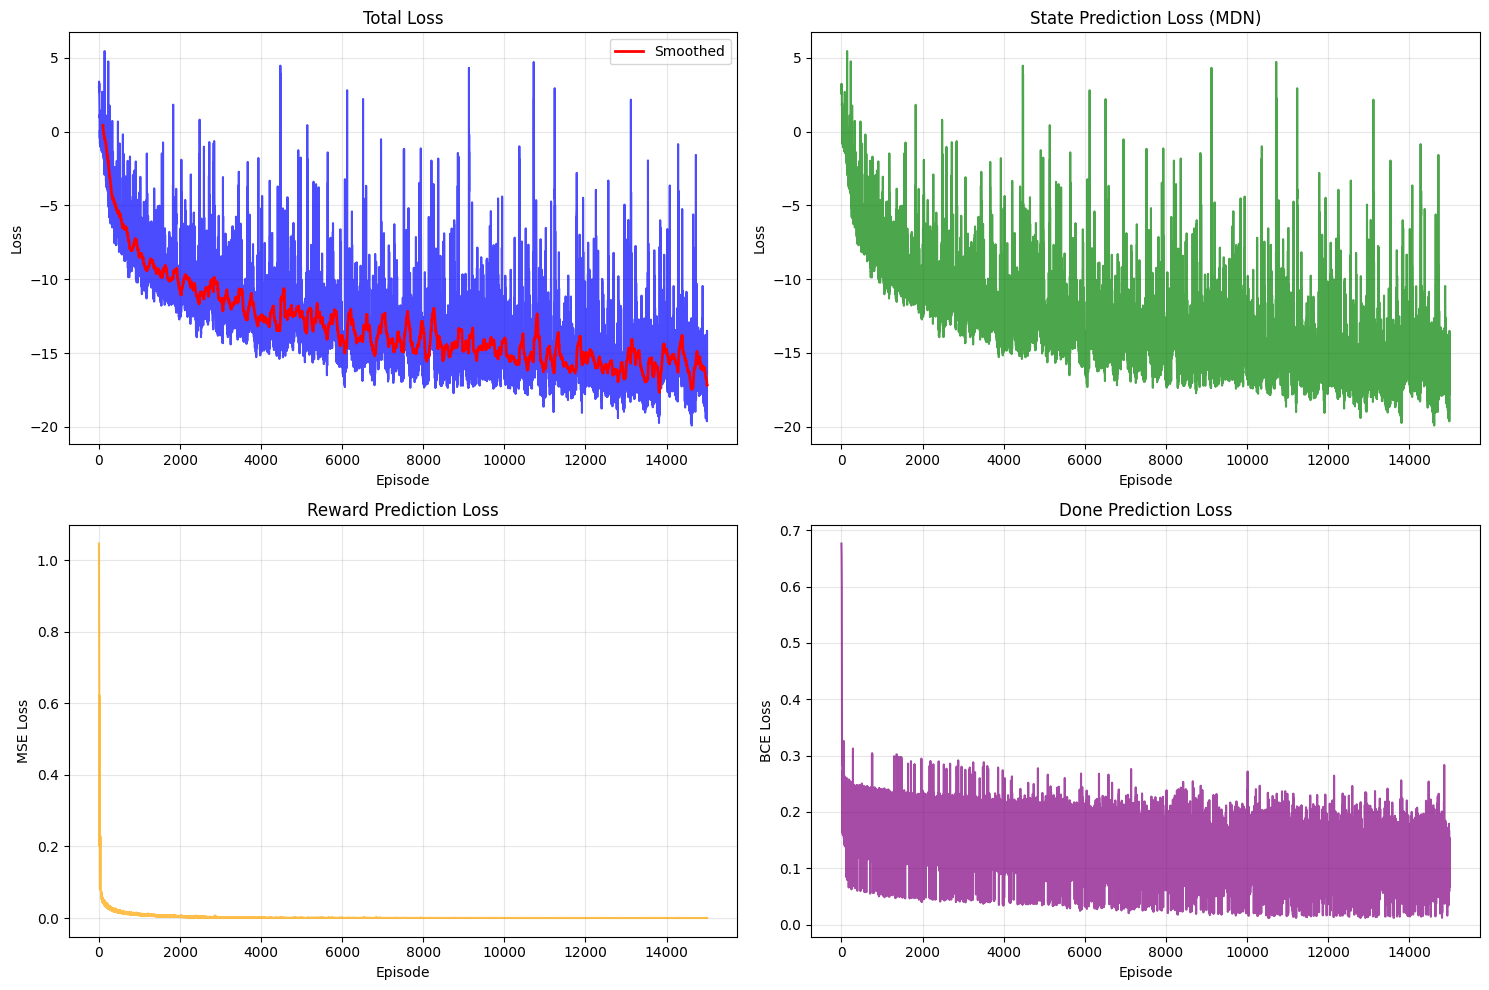


Training Complete!
Final Total Loss: -16.4188
Final State Loss: -16.4333
Final Reward Loss: 0.0000
Final Done Loss: 0.1454
Loss improvement: 4089.5% (from 0.4302 to -17.1625)


MDRNN(
  (lstm): LSTM(5, 256, batch_first=True)
  (pi_head): Linear(in_features=256, out_features=5, bias=True)
  (mu_head): Linear(in_features=256, out_features=20, bias=True)
  (sigma_head): Linear(in_features=256, out_features=20, bias=True)
  (reward_head): Linear(in_features=256, out_features=1, bias=True)
  (done_head): Linear(in_features=256, out_features=1, bias=True)
)

In [ ]:
# Create environment and model
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import torch
import os

hidden_dim = 256
training_episodes = 15000

env = gym.make('CartPole-v1')
model = MDRNN(state_dim=4, action_dim=1, hidden_dim=hidden_dim, n_gaussian=5)

# Train the model
train_mdrnn(env, model, n_episodes=training_episodes)

# Save the model
model_path = 'trained_models/mdrnn_cartpole.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'hidden_dim': hidden_dim,
    'training_episodes': training_episodes,
    'state_dim': 4,
    'action_dim': 1,
    'n_gaussian': 5
}, model_path)




## Plot predictions vs reality

Loaded model trained for 15000 episodes


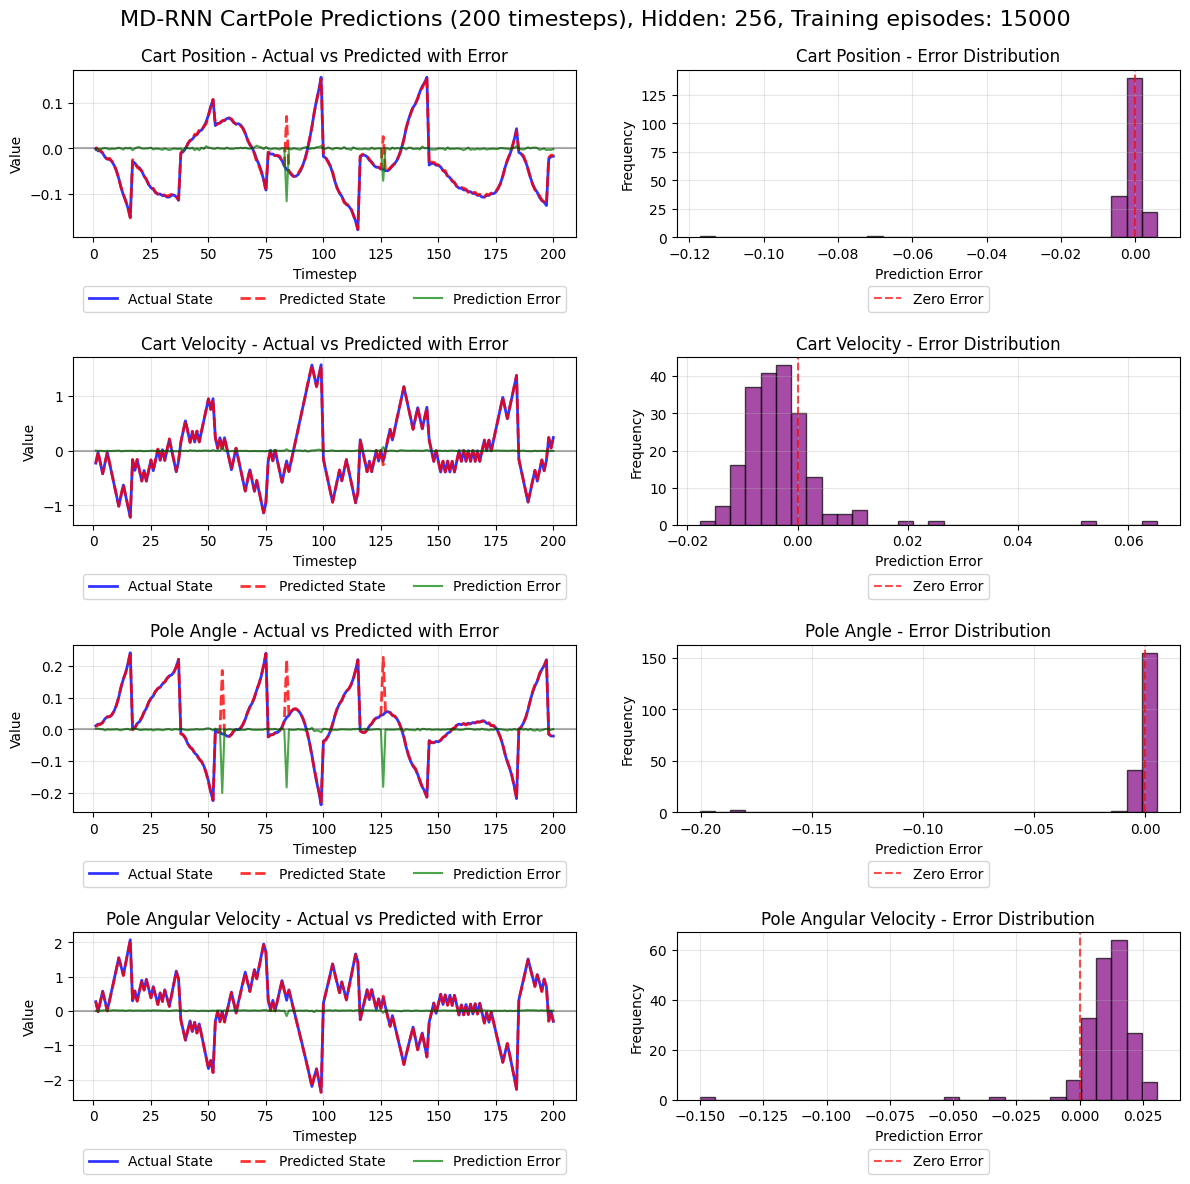

In [73]:
# Load the saved model
def load_model(model_path):
    checkpoint = torch.load(model_path)
    
    # Create model with saved parameters
    loaded_model = MDRNN(
        state_dim=checkpoint['state_dim'], 
        action_dim=checkpoint['action_dim'], 
        hidden_dim=checkpoint['hidden_dim'], 
        n_gaussian=checkpoint['n_gaussian']
    )
    
    # Load the state dict
    loaded_model.load_state_dict(checkpoint['model_state_dict'])
    
    return loaded_model, checkpoint

# Example usage:
model, info = load_model('trained_models/mdrnn_cartpole.pth')
print(f"Loaded model trained for {info['training_episodes']} episodes")


# Test prediction over 200 timesteps
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
model.eval()

# Initialize model hidden state
hidden = model.init_hidden(1, device)

# Collect actual trajectory
env = gym.make('CartPole-v1')
env.reset()  # Seed the environment for consistent initial state
state, _ = env.reset()
actual_states = []
predicted_states = []
actions_taken = []

print("Collecting 200-step trajectory and predictions...")

for step in range(200):
    # Record actual state
    # actual_states.append(state.copy())
    
    # Choose action (random for this test)
    action = env.action_space.sample()
    actions_taken.append(action)
    
    # Get model prediction
    state_tensor = torch.FloatTensor(state).unsqueeze(0).unsqueeze(0).to(device)
    action_tensor = torch.FloatTensor([[action]]).unsqueeze(0).to(device)
    
    with torch.no_grad():
        outputs = model(state_tensor, action_tensor, hidden)
        hidden = outputs['hidden']  # Update hidden state
        
        # Sample prediction from mixture
        predicted_next_state = model.sample_prediction(
            outputs['pi'][0, 0], 
            outputs['mu'][0, 0], 
            outputs['sigma'][0, 0]
        )
        predicted_states.append(predicted_next_state.cpu().numpy())
    
    # Take actual step in environment
    next_state, reward, terminated, truncated, _ = env.step(action)
    
    # Store next state for comparison
    actual_states.append(next_state.copy())
    done = terminated or truncated
    
    state = next_state
    if done:
        state, _ = env.reset()
        # Reset model hidden state when episode resets
        hidden = model.init_hidden(1, device)

# Convert to numpy arrays
actual_states = np.array(actual_states)      # Length 200: states at steps 0,1,2,...,199
predicted_states = np.array(predicted_states) # Length 200: predictions made at steps 0,1,2,...,199

predictions = predicted_states# All predictions (length 200)
actual_next = actual_states     # All actual states (length 200)
prediction_errors = actual_next - predictions

# Create plots - only 2 columns now
state_names = ['Cart Position', 'Cart Velocity', 'Pole Angle', 'Pole Angular Velocity']

fig, axes = plt.subplots(4, 2, figsize=(12, 12))  # Increased height for legends below
fig.suptitle('MD-RNN CartPole Predictions (200 timesteps), Hidden: ' + str(hidden_dim) + ', Training episodes: ' + str(training_episodes), fontsize=16, y=0.99)

# X-axis: timesteps where we made predictions (and can compare them)
x_axis = np.arange(1, len(predictions) + 1)

for i in range(4):  # For each state dimension
    # Plot 1: Actual vs Predicted states WITH prediction error line
    axes[i, 0].plot(x_axis, actual_next[:, i], 'b-', 
                   label='Actual State', linewidth=2, alpha=0.8)
    axes[i, 0].plot(x_axis, predictions[:, i], 'r--', 
                   label='Predicted State', linewidth=2, alpha=0.8)
    axes[i, 0].plot(x_axis, prediction_errors[:, i], 'g-', 
                   label='Prediction Error', linewidth=1.5, alpha=0.7)
    
    axes[i, 0].set_title(f'{state_names[i]} - Actual vs Predicted with Error')
    axes[i, 0].set_xlabel('Timestep')
    axes[i, 0].set_ylabel('Value')
    axes[i, 0].grid(True, alpha=0.3)
    axes[i, 0].axhline(y=0, color='k', linestyle='-', alpha=0.3)
    
    # Legend below plot
    axes[i, 0].legend(bbox_to_anchor=(0.5, -0.25), loc='upper center', ncol=3)
    
    # Plot 2: Error distribution
    axes[i, 1].hist(prediction_errors[:, i], bins=30, alpha=0.7, 
                   color='purple', edgecolor='black')
    axes[i, 1].axvline(x=0, color='red', linestyle='--', alpha=0.7, label='Zero Error')
    
    axes[i, 1].set_title(f'{state_names[i]} - Error Distribution')
    axes[i, 1].set_xlabel('Prediction Error')
    axes[i, 1].set_ylabel('Frequency')
    axes[i, 1].grid(True, alpha=0.3)
    
    # Legend below plot
    axes[i, 1].legend(bbox_to_anchor=(0.5, -0.25), loc='upper center')

plt.tight_layout()
plt.show()

